In [1]:
import numpy as np
import sys
import os
import pandas as pd
import json
import MyRiskFunctions
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Input
input files are in ./inputData/

./inputData/clientInfo.json : clients' holding

./inputData/hisInputData.csv : market data, including securities historical prices and volumes

In [2]:
# client information
client = pd.read_json("./inputdata/clientInfo.json")
client['UpdateTime'] = pd.to_datetime(client['UpdateTime'], unit='ms').dt.strftime("%Y-%m-%d")
client.sort_values(by=['UpdateTime'], inplace=True)
client.head()

,ClientID,Holding,Name,Type,MorningstarStyleBox,GICS,Credit Rating,Qty,Currency,CostPrice(Local currency),CurrentPrice(Local Currency),FX(toUSD),UpdateTime
4,AFE001,1398.HK,INDUSTRIAL AND COMMERCIAL BANK OF CHINA LTD,EQUITIES,Large Value,Financials,None,100000,HKD,4.67,4.860,0.1286,2024-10-10
5,AFE001,USD,US Dollar,CASH,None,None,None,200000,USD,1.00,1.000,1.0000,2024-10-10
6,AFE001,HKD,HK Dollar,CASH,None,None,None,50000,HKD,1.00,1.000,0.1286,2024-10-10
7,AFE001,UB#HSI RC2709N (51242),UBS AG - HSI R BULL CBBC SEP 2027 N (51242),ALTERNATIVES,None,None,None,50000,HKD,0.12,0.163,0.1286,2024-10-10
0,AFE001,AAPL.O,Apple,EQUITIES,Large Core,Technology,None,100,USD,231.84,226.960,1.0000,2024-11-10


In [3]:
### historical data
his = pd.read_csv("./inputData/hisInputData.csv")
his.set_index('date', inplace=True)
his = his.pivot(columns='instrument', values=['close', 'volume'])
his.head()
his.sort_index(ascending=True, inplace=True)
# his[('close', '0700.HK')]

In [4]:
currentTime = '2024-11-10'

In [5]:
outputJson = []

## Begin the report

Code cell is for calculating. Its output and markdown cell is report's contents.

## Performance Analysis
### Asset Allocation

In [6]:
base1 = pd.DataFrame(columns=['categories'], data=['EQUITIES', 'FIXED INCOME & PREFERREDS', 'ALTERNATIVES', 'CASH'])
client['MV_USD'] = client['Qty']*client['CurrentPrice(Local Currency)']*client['FX(toUSD)']
agg1 = client.groupby(['UpdateTime', 'Type']).agg(MV_USD_sum_Asset=pd.NamedAgg(column='MV_USD', aggfunc='sum')).reset_index()
agg2 = client.groupby(['UpdateTime']).agg(MV_USD_sum=pd.NamedAgg(column='MV_USD', aggfunc='sum')).reset_index()
agg3 = pd.merge(agg1, agg2, how='left', left_on='UpdateTime', right_on='UpdateTime')
agg3['percentage'] = agg3['MV_USD_sum_Asset']/ agg3['MV_USD_sum']
agg3.set_index('Type', inplace=True)
agg3 = agg3.pivot(columns='UpdateTime', values='percentage')
agg3.reset_index(inplace=True)
agg4 = pd.merge(base1, agg3, how='left', left_on='categories', right_on='Type')
agg4.drop(columns=['Type'], inplace=True)
agg4.columns = ['categories', 'last month', 'current']
agg4.fillna(0, inplace=True)
agg4['difference'] = agg4['current'] - agg4['last month']
agg4

,categories,last month,current,difference
0,EQUITIES,0.231499,0.703946,0.472447
1,FIXED INCOME & PREFERREDS,0.000000,0.000000,0.000000
2,ALTERNATIVES,0.003882,0.000000,-0.003882
3,CASH,0.764619,0.000000,-0.764619


In [7]:
outputJson.append(agg4)

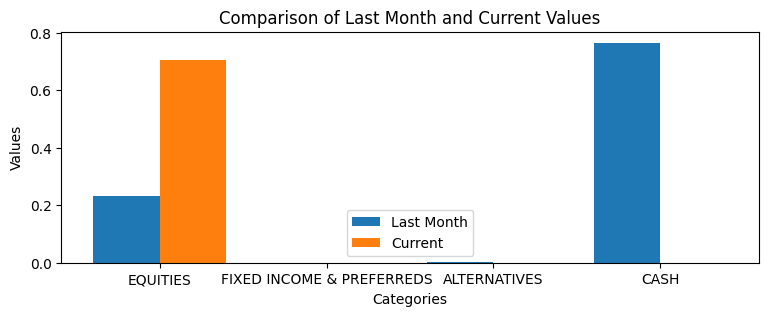

In [8]:
x = range(len(agg4['categories']))
plt.figure(figsize=(9, 3))
plt.bar(x, agg4['last month'], width=0.4, label='Last Month', align='center')
plt.bar([i + 0.4 for i in x], agg4['current'], width=0.4, label='Current', align='center')

plt.xticks([i + 0.2 for i in x], agg4['categories'])

plt.title('Comparison of Last Month and Current Values')
plt.xlabel('Categories')
plt.ylabel('Values')

plt.legend()

plt.show()

In [9]:
cond1 = client['UpdateTime'] == client['UpdateTime'].min() # remember to change to max
cond2 = client['Type'] == 'CASH'
agg1 = client[cond1 & cond2] 

agg1[['Currency', 'MV_USD']]

,Currency,MV_USD
5,USD,200000.0
6,HKD,6430.0


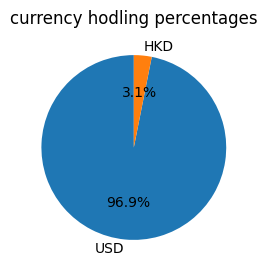

In [10]:
plt.figure(figsize=(3, 3))
plt.pie(agg1['MV_USD'], labels=agg1['Currency'], autopct='%1.1f%%', startangle=90)
plt.title('currency hodling percentages')
plt.show()

In [11]:
outputJson.append(agg1)

### Holding

In [12]:
# current holding each components' percentages:

cond1 = client['UpdateTime'] == client['UpdateTime'].max()
agg1 = client[cond1]
agg1['percentage'] = agg1['MV_USD'] / agg1['MV_USD'].sum()
agg1[['Holding', 'percentage', 'Currency']] # used to backtesting
holding_dict = agg1[['Holding', 'percentage', 'Currency']].set_index('Holding').to_dict()
# holding_dict

C:\Users\82438\AppData\Local\Temp\ipykernel_19228\2466312752.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg1['percentage'] = agg1['MV_USD'] / agg1['MV_USD'].sum()


In [13]:
clsp = his['close']
# in USD
for holding in agg1['Holding'].to_list():
    if holding_dict['Currency'][holding] == 'USD':
        clsp[holding] = clsp[holding]
    else:
        clsp[holding] = clsp[holding]*clsp[holding_dict['Currency'][holding]+'/USD']
init_price = {}
for holding in agg1['Holding'].to_list():
    init_price[holding] = clsp[clsp[holding].isnull() == False][holding].to_list()[0]
    clsp[holding] = clsp[holding] / init_price[holding]
# clsp
# find the first not null value

C:\Users\82438\AppData\Local\Temp\ipykernel_19228\3354289039.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clsp[holding] = clsp[holding]
C:\Users\82438\AppData\Local\Temp\ipykernel_19228\3354289039.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clsp[holding] = clsp[holding]*clsp[holding_dict['Currency'][holding]+'/USD']
C:\Users\82438\AppData\Local\Temp\ipykernel_19228\3354289039.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

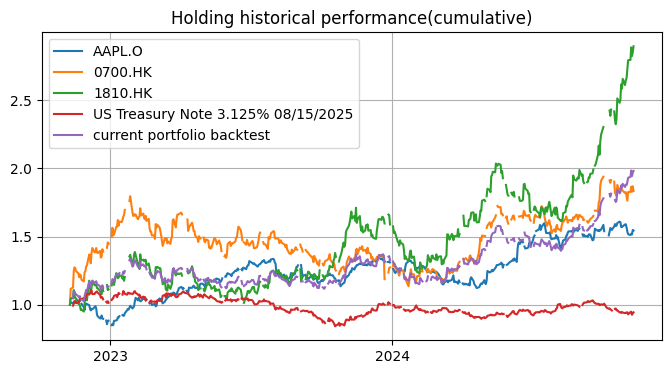

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))


# 绘制折线图
for holding in agg1['Holding'].to_list():
    ax.plot(pd.to_datetime(clsp.index), clsp[holding], label=holding)

p = np.dot(np.array(clsp[agg1['Holding'].to_list()]), np.array(list(holding_dict['percentage'].values())).reshape(-1, 1))
ax.plot(pd.to_datetime(clsp.index), p, label='current portfolio backtest')
# 设置图例
ax.legend()

# 设置标题和轴标签
ax.set_title('Holding historical performance(cumulative)')
# 设置x轴的刻度定位器为每年的第一天
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid()
# 显示图表
plt.show()

In [15]:
clsp['p'] = p
outputJson.append(clsp)

C:\Users\82438\AppData\Local\Temp\ipykernel_19228\3449810736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clsp['p'] = p


In [16]:
riskmetric = {}
for holding in agg1['Holding'].to_list():
    metrics = {}
    # holding percentage
    metrics['percentage'] = holding_dict['percentage'][holding]
    # current holding's gross_return in past 1 month
    date = pd.to_datetime(currentTime)
    # 找到前一个月的日期
    m1Date = (date - pd.DateOffset(months=1)).strftime('%Y-%m-%d')
    priceTemp = his['close']
    priceTemp = priceTemp[priceTemp.index >= m1Date]
    returns = priceTemp[holding].pct_change().dropna()
    metrics['gross_return(1m)'] = MyRiskFunctions.gross_return(returns)
    metrics['max drawdown(1m)'] = MyRiskFunctions.drawdown(returns)
    metrics['volatility(1m)'] = MyRiskFunctions.volatility(returns)
    
    # 找到前3个月的日期
    m1Date = (date - pd.DateOffset(months=3)).strftime('%Y-%m-%d')
    priceTemp = his['close']
    priceTemp = priceTemp[priceTemp.index >= m1Date]
    returns = priceTemp[holding].pct_change().dropna()
    metrics['gross_return(3m)'] = MyRiskFunctions.gross_return(returns)
    metrics['max drawdown(3m)'] = MyRiskFunctions.drawdown(returns)
    metrics['volatility(3m)'] = MyRiskFunctions.volatility(returns)

    # 找到前6个月的日期
    m1Date = (date - pd.DateOffset(months=6)).strftime('%Y-%m-%d')
    priceTemp = his['close']
    priceTemp = priceTemp[priceTemp.index >= m1Date]
    returns = priceTemp[holding].pct_change().dropna()
    metrics['gross_return(6m)'] = MyRiskFunctions.gross_return(returns)
    metrics['max drawdown(6m)'] = MyRiskFunctions.drawdown(returns)
    metrics['volatility(6m)'] = MyRiskFunctions.volatility(returns)


    riskmetric[holding] = metrics


riskmetric = pd.DataFrame.from_dict(riskmetric, orient='index')

riskmetric.index.name = 'instrument'
riskmetric

C:\Users\82438\AppData\Local\Temp\ipykernel_19228\938828901.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = priceTemp[holding].pct_change().dropna()
C:\Users\82438\AppData\Local\Temp\ipykernel_19228\938828901.py:30: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = priceTemp[holding].pct_change().dropna()
C:\Users\82438\AppData\Local\Temp\ipykernel_19228\938828901.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_

,percentage,gross_return(1m),max drawdown(1m),volatility(1m),gross_return(3m),max drawdown(3m),volatility(3m),gross_return(6m),max drawdown(6m),volatility(6m)
instrument,,,,,,,,,,
AAPL.O,0.085663,-0.002593,0.061189,0.010998,0.025715,0.061189,0.012216,0.218381,0.117494,0.014646
0700.HK,0.207647,-0.041021,0.077940,0.019926,0.111463,0.089969,0.016441,0.112639,0.115365,0.015941
1810.HK,0.410635,0.191579,0.044211,0.022177,0.674556,0.049231,0.021742,0.461777,0.208208,0.021801
US Treasury Note 3.125% 08/15/2025,0.296054,-0.013941,0.047765,0.010291,-0.046706,0.102264,0.007870,0.021581,0.102264,0.008404


In [17]:
outputJson.append(riskmetric)

## Market Risk

In [18]:
marketrisk = {}
for holding in agg1['Holding'].to_list():
    metrics = {}
    # holding percentage
    metrics['percentage'] = holding_dict['percentage'][holding]
    # current holding's contribution in past 1 month
    date = pd.to_datetime(currentTime)
    # 找到前一个月的日期
    priceTemp = his['close']
    returns = priceTemp[holding].pct_change().dropna()
    metrics['VaR'] = MyRiskFunctions.VaR_Hist(returns)
    metrics['CVaR'] = MyRiskFunctions.CVaR_Hist(returns)
    # metrics['volatility(1m)'] = MyRiskFunctions.volatility(returns)


    marketrisk[holding] = metrics


marketrisk = pd.DataFrame.from_dict(marketrisk, orient='index')

rc, portfolio_std_dev = MyRiskFunctions.risk_contribution(np.array(list(holding_dict['percentage'].values())), his['close'][list(holding_dict['percentage'].keys())])
marketrisk['risk_contribution'] = rc / portfolio_std_dev
marketrisk.index.name = 'instrument'
marketrisk

C:\Users\82438\AppData\Local\Temp\ipykernel_19228\2026448939.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = priceTemp[holding].pct_change().dropna()
c:\Users\82438\OneDrive - HKUST Connect\JobApplication\Ultra Science Technology\AFE\RiskAnalysisReport\src\MyRiskFunctions.py:260: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna(how='all')


,percentage,VaR,CVaR,risk_contribution
instrument,,,,
AAPL.O,0.085663,0.021623,0.030285,0.016483
0700.HK,0.207647,0.027510,0.038596,0.244160
1810.HK,0.410635,0.035294,0.045083,0.699012
US Treasury Note 3.125% 08/15/2025,0.296054,0.016104,0.019843,0.040345


In [19]:
outputJson.append(marketrisk)

### Portfolio in last 2 years' hypothetical performance

C:\Users\82438\AppData\Local\Temp\ipykernel_19228\2109109881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  priceTemp['portfolio'] = p
C:\Users\82438\AppData\Local\Temp\ipykernel_19228\2109109881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  priceTemp['Quarter'] = pd.to_datetime(priceTemp.index).to_period('Q')
C:\Users\82438\AppData\Local\Temp\ipykernel_19228\2109109881.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. 

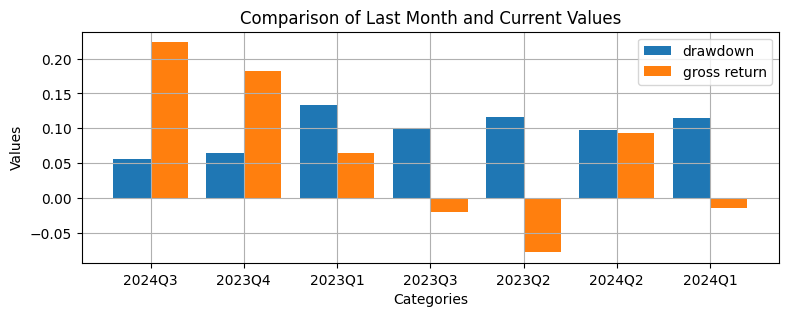

In [20]:
priceTemp = his['close']
p = np.dot(np.array(clsp[agg1['Holding'].to_list()]), np.array(list(holding_dict['percentage'].values())).reshape(-1, 1))
priceTemp['portfolio'] = p
priceTemp['Quarter'] = pd.to_datetime(priceTemp.index).to_period('Q')
simu = {}
quaters = priceTemp['Quarter'].value_counts()
for q in quaters[quaters >= 50].index:
    metrics = {}
    dfq = priceTemp[priceTemp['Quarter'] == q]
    po = dfq['portfolio'].pct_change().dropna()
    metrics['drawdown'] = MyRiskFunctions.drawdown(po)
    metrics['gross_return'] = MyRiskFunctions.gross_return(po)

    simu[q] = metrics

x = range(len(simu.keys()))
plt.figure(figsize=(9, 3))
plt.bar(x, pd.DataFrame(simu).T['drawdown'], width=0.4, label='drawdown', align='center')
plt.bar([i + 0.4 for i in x], pd.DataFrame(simu).T['gross_return'], width=0.4, label='gross return', align='center')

plt.xticks([i + 0.2 for i in x], list(simu.keys()))

plt.title('Comparison of Last Month and Current Values')
plt.xlabel('Categories')
plt.ylabel('Values')

plt.legend()
plt.grid()
plt.show()

In [21]:
simu = pd.DataFrame(simu).T
simu.index = simu.index.astype(str)
outputJson.append(simu)

## Liquity Risk

In [22]:
# calculate ADTV of  30days
adtv = {}
for holding in agg1['Holding'].to_list():
    metric = {}
    volumetemp = his['volume']
    t1 = int(volumetemp[holding].tail(30).mean())
    t2 = client[(client['UpdateTime'] == client['UpdateTime'].max()) & (client['Holding'] == holding)]['Qty'].tolist()[0]
    metric['ADTV'] = t1
    metric['Holding'] = t2
    metric['Holding/ADTV'] = t2/t1
    adtv[holding] = metric
pd.DataFrame(adtv).T

,ADTV,Holding,Holding/ADTV
AAPL.O,42767395.0,100.0,0.000002
0700.HK,24893448.0,1000.0,0.000040
1810.HK,188096910.0,30000.0,0.000159
US Treasury Note 3.125% 08/15/2025,263.0,1000.0,3.802281


In [23]:
outputJson.append(pd.DataFrame(adtv).T)

## Concentration Risk

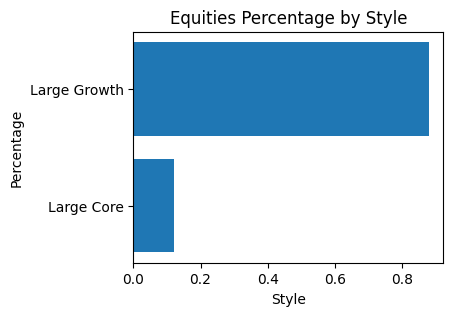

In [24]:
# 绘制水平柱状图
plt.figure(figsize=(4, 3))
data = client[(client['UpdateTime'] == client['UpdateTime'].max()) & (client['MorningstarStyleBox'].isnull() == False)][['MorningstarStyleBox', 'MV_USD']]
agg1 = data.groupby(['MorningstarStyleBox']).agg(per=pd.NamedAgg(column='MV_USD', aggfunc='sum'))
agg1['per'] = agg1['per'] / agg1['per'].sum()
plt.barh(agg1.index, agg1['per'])

# 设置标题和轴标签
plt.title('Equities Percentage by Style')
plt.xlabel('Style')
plt.ylabel('Percentage')

# 显示图表
plt.show()

In [25]:
outputJson.append(agg1)

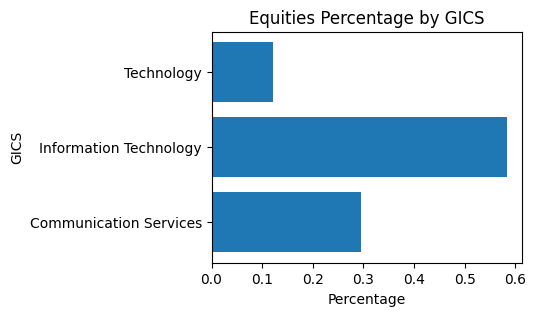

In [26]:
# 绘制水平柱状图
plt.figure(figsize=(4, 3))
data = client[(client['UpdateTime'] == client['UpdateTime'].max()) & (client['GICS'].isnull() == False)][['GICS', 'MV_USD']]
agg1 = data.groupby(['GICS']).agg(per=pd.NamedAgg(column='MV_USD', aggfunc='sum'))
agg1['per'] = agg1['per'] / agg1['per'].sum()
plt.barh(agg1.index, agg1['per'])

# 设置标题和轴标签
plt.title('Equities Percentage by GICS')
plt.xlabel('Percentage')
plt.ylabel('GICS')

# 显示图表
plt.show()

In [27]:
outputJson.append(agg1)

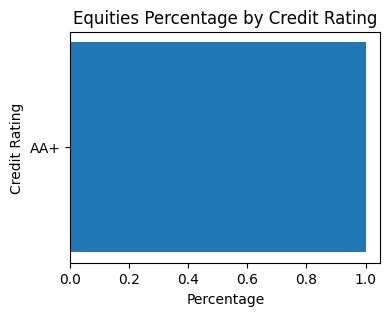

In [28]:
# 绘制水平柱状图
plt.figure(figsize=(4, 3))
data = client[(client['UpdateTime'] == client['UpdateTime'].max()) & (client['Credit Rating'].isnull() == False)][['Credit Rating', 'MV_USD']]
data['Credit Rating'] = data['Credit Rating'].apply(lambda x: x.split(',')[0])
agg1 = data.groupby(['Credit Rating']).agg(per=pd.NamedAgg(column='MV_USD', aggfunc='sum'))
agg1['per'] = agg1['per'] / agg1['per'].sum()
plt.barh(agg1.index, agg1['per'])

# 设置标题和轴标签
plt.title('Equities Percentage by Credit Rating')
plt.xlabel('Percentage')
plt.ylabel('Credit Rating')

# 显示图表
plt.show()

In [29]:
outputJson.append(agg1)

## Correlation and tail risk

In [30]:
temp = clsp[client[client['UpdateTime'] == client['UpdateTime'].max()]['Holding'].to_list()]
data = MyRiskFunctions.calculate_correlation(temp.dropna())

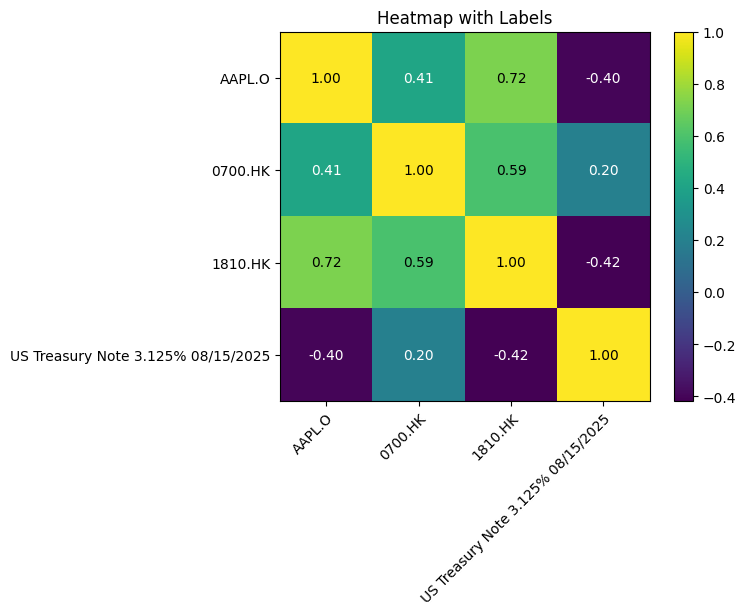

In [31]:
fig, ax = plt.subplots()
cax = ax.imshow(data, cmap='viridis')
fig.colorbar(cax)

# 设置行和列标签
cols = client[client['UpdateTime'] == client['UpdateTime'].max()]['Holding'].to_list()
rows = cols
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(rows)))
ax.set_xticklabels(cols)
ax.set_yticklabels(rows)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', color='white' if data[i, j] < 0.5 else 'black')

# 旋转列标签以便于阅读
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# 添加标题
ax.set_title('Heatmap with Labels')

# 显示热力图
plt.show()

In [32]:
outputJson.append(pd.DataFrame(columns=cols, data=data))

In [33]:
dict_list = []
for df in outputJson:
    try:
        dict_list.append(df.to_dict(orient='records'))
    except Exception as e:
        print(df)
# 将字典列表转换为JSON字符串
json_str = json.dumps(dict_list, indent=4)

# 保存到文件
with open('./outputJson/dataframes.json', 'w') as f:
    f.write(json_str)